# Regresióon Lineal

## Métodos de Regresión
Estos métodos buscan explicar o predecir una variable a partir de otra u otras variables encontrando relaciones matemáticas lineales. 

### Definiciones:
- Variable independiente: Variables que serán usadas para describir a la variable dependiente.
- Variable dependiente: Variable que será predicha o explicada por medio del modelo de regresión.
- Coeficientes del modelo: Valores numéricos que acompañan la variable independiente. Generalmente se denotan con la letra $\beta$ 
- Record: En datos estructurados en tablas (DataFrames) un record, corresponde a una fila.
- Residuos: Son el resultado de la diferencia entre el valor de la variable independiente predicha y la variable independiente real.  $Residuo = y_{real} - y_{predicha}$

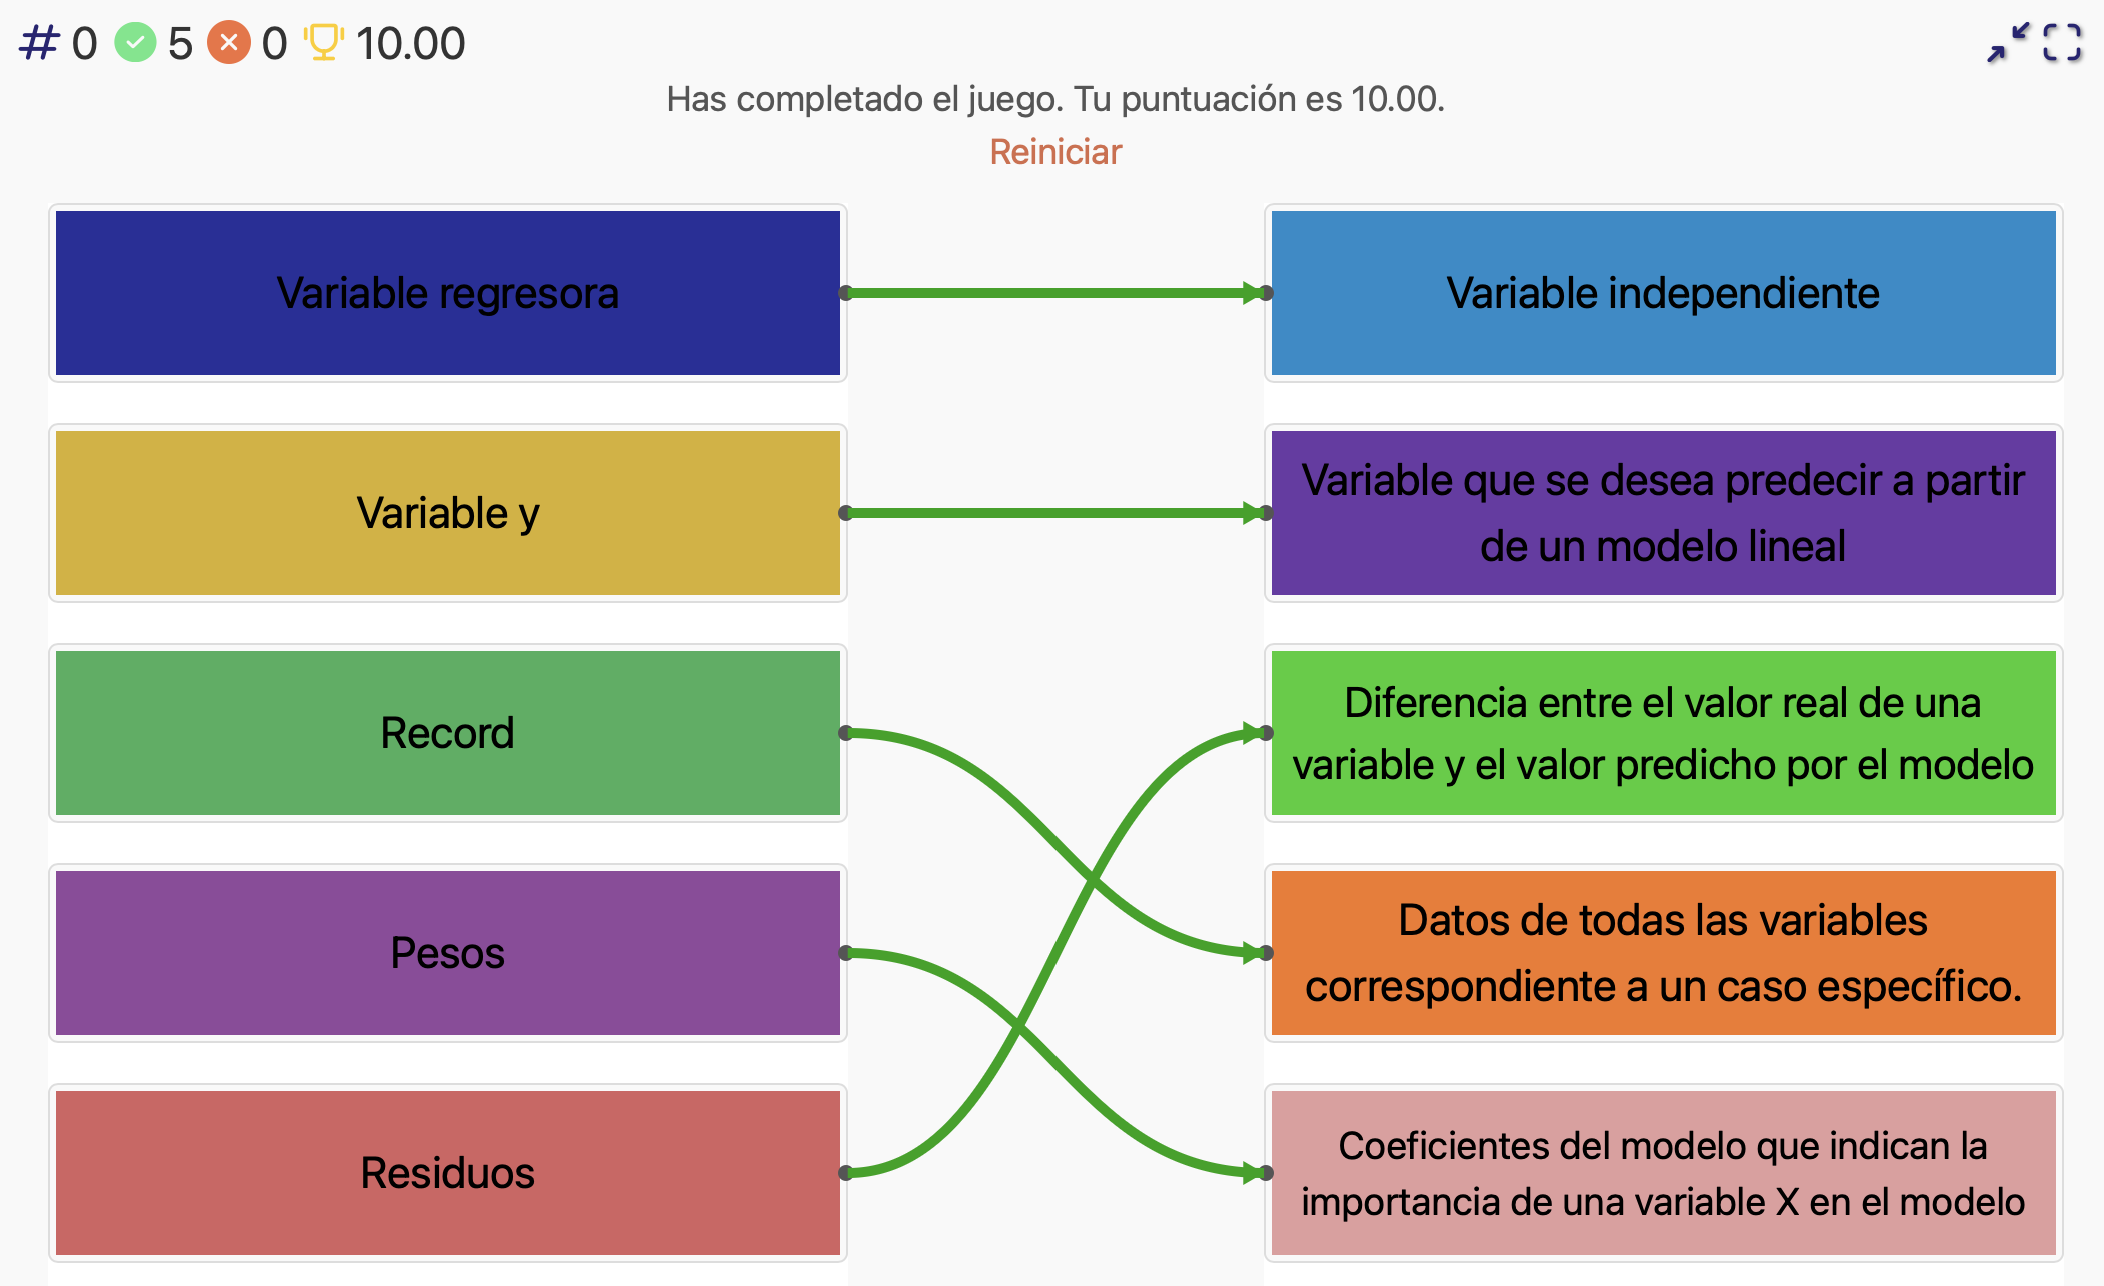

# Regresión Lineal Simple
En este caso los modelos cuentan con una única variable X y son de la forma: 
$y=\beta_{0} + \beta_{1}X$

# Carga de datos

In [9]:
import pandas as pd 

data = pd.read_excel("data_validación.xlsx")

X = data[['X']]

y = data["y"]

# Creación del Modelo

Seguidamente, debemos crear y ajustar el modelo con ayuda de la librería SciKit_learn


In [10]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression(fit_intercept=True) # se crea un objeto de la clase LinearRegression 
modelo.fit(X,y) # luego se ajusta el objeto con el método fit() a los datos de interés

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- fit_intercept: Si calcular la intercepción para este modelo. Si se establece en Falso, no se utilizará ninguna intercepción en los cálculos (es decir, se espera que los datos se centren).
    Por lo tanto se espera que los no se centren.
- copy_X: Si es verdadero, X se copiará; de lo contrario, puede sobrescribirse.
    Por lo tanto X se copiará.
- tol: Este parámetro no tiene efecto cuando se ajusta a datos densos. Debido a que su valor es el predeterminado. (predeterminado=1e-6)
- n_jobs: El número de trabajos a utilizar para el cálculo. Esto solo proporcionará aceleración en caso de problemas suficientemente grandes, es decir, si en primer lugar n_targets > 1 y en segundo lugar X es es escaso o si el positivo se establece en Verdadero. Ninguno significa 1 a menos que en un contexto joblib.parallel_backend. -1 significa usar todos los procesadores. Consulte el Glosario para obtener más detalles.
    None, significa 1. Por lo tanto hay un trabajo a utilizar para el cálculo.
- positive: Cuando se establece en True, obliga a los coeficientes a ser positivos. Esta opción solo es compatible con matrices densas.
    Por lo tanto los coeficientes no son obligados a ser positivos.

# Coeficiente del modelo
Los coeficientes del modelo son atributos del objeto "modelo" creado, $\beta_{0}$ está en el atributo intercept_ y  $\beta_{1}$ en el atributo coef_

In [11]:
import numpy as np


beta0 = modelo.intercept_ 
beta1 = modelo.coef_

x_plot = np.linspace(58,97,20) #rango de datos de un X para probar

y_plot = beta0 + beta1*x_plot #valor de y predichos por el modelo para los x_plot

# Graficar el Modelo
Grafiquemos los datos x_plot y y_plot generados antes, contra los datos originales. 

/var/folders/6g/6n30jc0j6jq8ktywt94l6q740000gn/T/ipykernel_28844/2014772499.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X,y,c=[245/255, 149/255, 39/255],label="Datos reales")


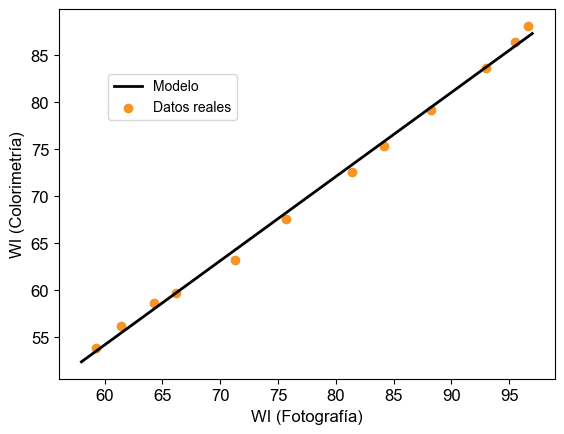

In [13]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots()

ax.plot(x_plot,y_plot,c='k',lw=2, label="Modelo")
ax.scatter(X,y,c=[245/255, 149/255, 39/255],label="Datos reales")

ax.set_ylabel("WI (Colorimetría)",fontname = "Arial",fontsize=12)
ax.set_xlabel("WI (Fotografía)", fontname="Arial",fontsize=12)

plt.xticks(fontfamily = "Arial",fontsize=12)
plt.yticks(fontfamily = "Arial",fontsize=12)
ax.legend(prop={'family':"Arial", 'size':10},loc=(0.1,0.7),fontsize=12)

Según la gráfica, se concluye que la relación que tienen el índice de blancura medido con fotografía y medido con colorimetría es similar en gran proporción. 

# Regresión lineal múltiple
Las variables dependientes requieren ser explicadas a partir de la variable independiente 

# CArga de Datos

In [14]:
import pandas as pd

df = pd.read_excel('diabetes.xlsx')

# Análisis de correlación:
Permite realizar la selección de variables regresoras a partir de una matriz de correlación de datos.


In [15]:
import seaborn as sns

corr_matrix = df.corr()

plt.figure(figsize=(8, 6))

plt.title("Matriz de Correlación ")

#no importa si la correlación es positiva o negativa, entonces se puede graficar abs
sns.heatmap(abs(corr_matrix.values), cmap='vlag', fmt=".2f", linewidths=0.5,xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)

plt.tight_layout()

ModuleNotFoundError: No module named 'seaborn'